# Variational AutoEncoder example
This notebook is a copy of [Francois Chollet's example](https://keras.io/examples/generative/vae/) but modified for online learning. In particular, some goals are:
1. test computational performance scaling (CPUs, GPUs)
2. test model performance while saving and fitting again (in particular, adding more data instead of having all the data available at once).
3. integrations with DVC

## Environment set up
Based on the [Keras](https://keras.io/getting_started/) and [Tensorflow](https://www.tensorflow.org/install) instructions. We need Keras 3+ to be able to run this example. A simple `conda install tensorflow` will install TF 2.12 and Keras 2. I also tried using Python 3.11, but it appears that there may be some issues with underlying C libraries, so use Python 3.9.

In [1]:
install = False
conda_env_name = 'tf-cpu-py39'

# Path if using default options in JupyterLab workflow
#conda_base_path="~/pw/software/.miniconda3c/"

# Path if using attached storage
conda_base_path="/pw/apps/.miniconda3c/"

if (install):
    # Need a new env since default is Python 3.11+
    ! conda create --name {conda_env_name} -q -y python=3.9
    
    # The following are required for connecting the kernel to a notebook:
    ! conda install --name {conda_env_name} -q -y requests
    ! conda install --name {conda_env_name} -q -y ipykernel
    ! conda install --name {conda_env_name} -q -y -c anaconda jinja2
    
    # Additional packages for data wrangling and plotting
    ! conda install --name {conda_env_name} -q -y pandas matplotlib
    
    # Ensure pip is up to date, then install TF:
    # Each Conda env has its own pip, so need to activate.
    # All pip installs must be after conda installs.
    ! source {conda_base_path}/etc/profile.d/conda.sh; conda activate {conda_env_name}; pip install --upgrade pip
    ! source {conda_base_path}/etc/profile.d/conda.sh; conda activate {conda_env_name}; pip install tensorflow
    ! source {conda_base_path}/etc/profile.d/conda.sh; conda activate {conda_env_name}; pip install tensorboard-plugin-profile
    
    # The environment can be exported with:
    ! conda env export --name {conda_env_name} > ./requirements/{conda_env_name}.yaml

## Sample performance results:

Memory usage is around 2.5 GB

2 CPUs -> 70 ms/step, ~40s per epoch -> 20 mins

4 CPUs -> 40 ms/step, ~22s per epoch -> 11 mins

8 CPUs -> 24 ms/step, ~13s per epoch -> 7 mins

T4 GPU -> ???

In [2]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import ops
from keras import layers

2025-06-18 10:39:16.883539: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750243156.903326   47286 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750243156.909810   47286 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750243156.924505   47286 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750243156.924521   47286 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1750243156.924522   47286 computation_placer.cc:177] computation placer alr

In [3]:
model_dir = './model_d'
os.makedirs(model_dir, exist_ok = True)

## Create sampling layer

In [4]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon

## Build the encoder

In [5]:
latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

2025-06-18 10:39:18.790970: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

## Build the decoder

In [6]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

## Define the VAE as a `Model` with a custom `train_step`

In [7]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = ops.mean(
                ops.sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

## Train the VAE

In [8]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
# 30 epochs is better, but shorten to 20 for saving time in workshop
history = vae.fit(mnist_digits, epochs=20, batch_size=128)

Epoch 1/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - kl_loss: 0.6904 - loss: 264.1808 - reconstruction_loss: 263.4905
Epoch 2/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - kl_loss: 5.6050 - loss: 175.1883 - reconstruction_loss: 169.5833
Epoch 3/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - kl_loss: 6.0507 - loss: 168.5832 - reconstruction_loss: 162.5325
Epoch 4/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - kl_loss: 6.2396 - loss: 164.9303 - reconstruction_loss: 158.6907
Epoch 5/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - kl_loss: 6.3303 - loss: 162.2188 - reconstruction_loss: 155.8885
Epoch 6/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - kl_loss: 6.3773 - loss: 161.1451 - reconstruction_loss: 154.7678
Epoch 7/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - kl_loss: 6.3984 - loss: 159.7684 - reconstruction_loss: 153.3699
Epoch 8/20
547/547 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - kl_loss: 6.3744 - loss: 158.6961 - reconstruction_loss: 152.3217
Epoch 9/20
547/547 ━━━━━━━━━━━━━

In [9]:
hist_pd = pd.DataFrame(history.history)
hist_pd.to_csv(os.path.join(model_dir, f'history.csv'), index = False)

## Display a grid of reconstructed digits in the latent space

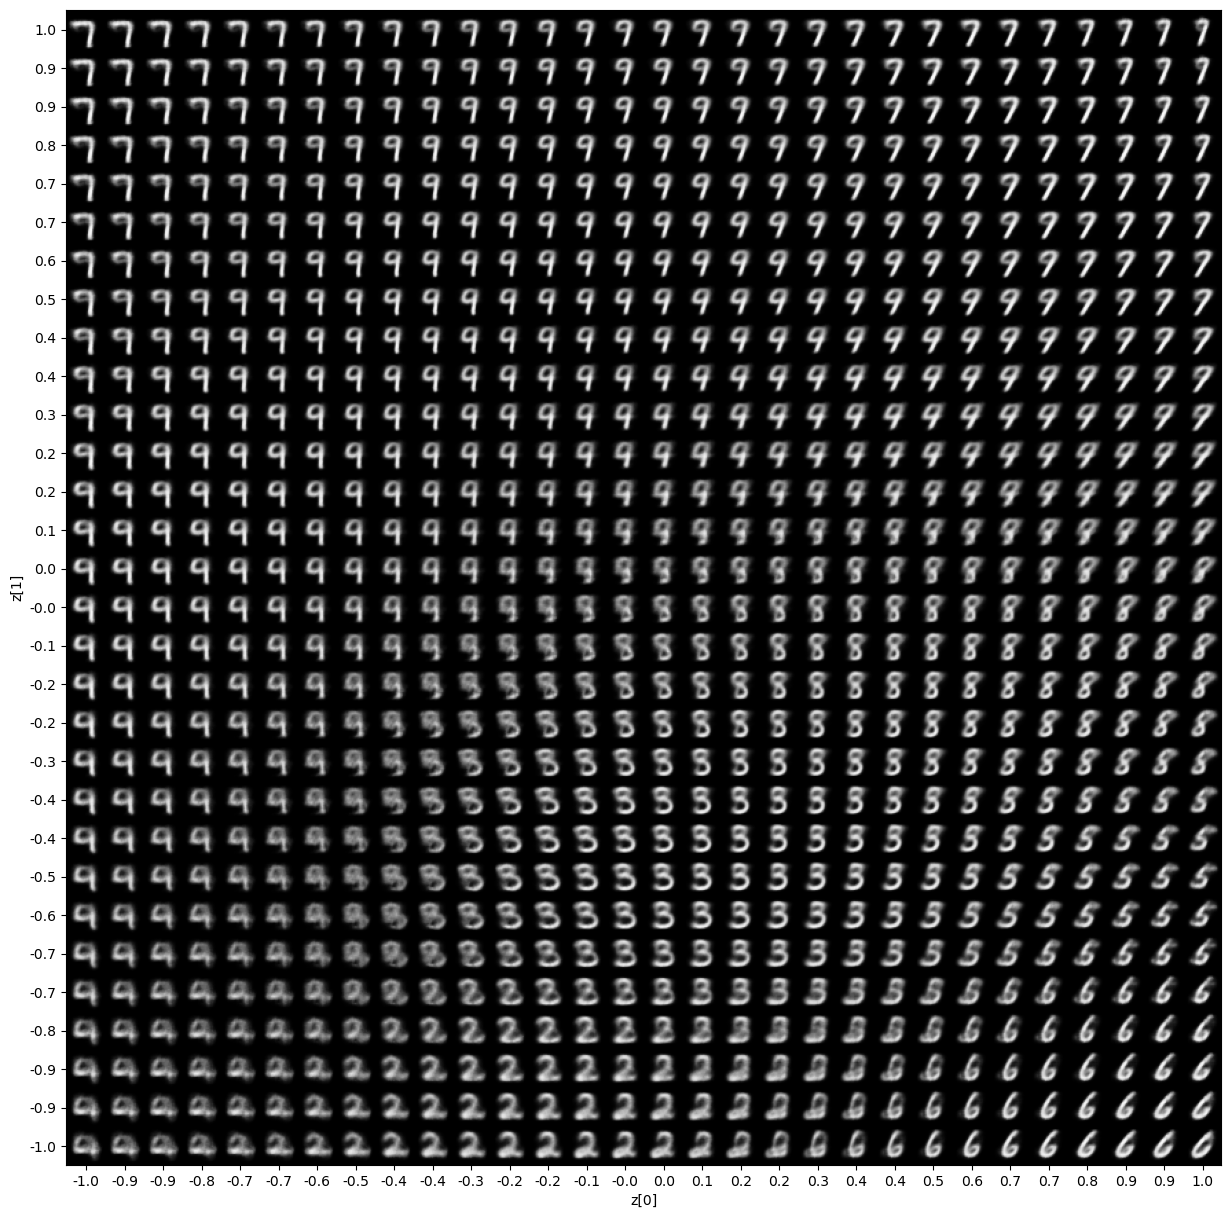

In [10]:
import matplotlib.pyplot as plt


def plot_latent_space(vae, n=30, figsize=15):
    # display a n*n 2D manifold of digits
    digit_size = 28
    scale = 1.0
    figure = np.zeros((digit_size * n, digit_size * n))
    # linearly spaced coordinates corresponding to the 2D plot
    # of digit classes in the latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae.decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_latent_space(vae)

## Display how the latent space clusters digits

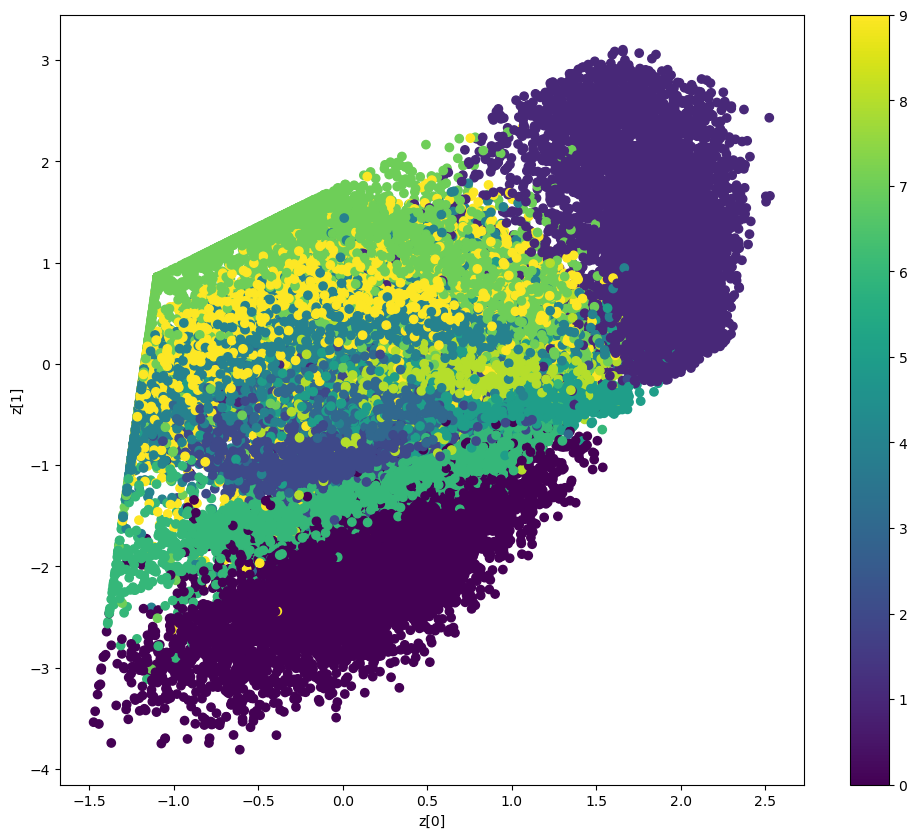

In [11]:
def plot_label_clusters(vae, data, labels):
    # display a 2D plot of the digit classes in the latent space
    z_mean, _, _ = vae.encoder.predict(data, verbose=0)
    plt.figure(figsize=(12, 10))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.show()


(x_train, y_train), _ = keras.datasets.mnist.load_data()
x_train = np.expand_dims(x_train, -1).astype("float32") / 255

plot_label_clusters(vae, x_train, y_train)